In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [5]:
df_fea = pd.read_csv("features.csv")

In [6]:
df_train = pd.read_csv("train.csv")

In [7]:
df_test = pd.read_csv("test.csv")

In [8]:
df_store = pd.read_csv("stores.csv")

In [9]:
df_train_feature = pd.merge(df_train, df_fea, on=['Store', 'Date'], how='left')

In [10]:
df = pd.merge(df_train_feature, df_store, on='Store', how='left')

In [11]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False,A,151315


In [12]:
df.tail()

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y,Type,Size
421565,45,98,2012-09-28,508.37,False,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684,False,B,118221
421566,45,98,2012-10-05,628.10,False,64.89,3.985,5046.74,NaN,18.82,2253.43,2340.01,192.170412,8.667,False,B,118221
421567,45,98,2012-10-12,1061.02,False,54.47,4.000,1956.28,NaN,7.89,599.32,3990.54,192.327265,8.667,False,B,118221
421568,45,98,2012-10-19,760.01,False,56.47,3.969,2004.02,NaN,3.18,437.73,1537.49,192.330854,8.667,False,B,118221
421569,45,98,2012-10-26,1076.80,False,58.85,3.882,4018.91,58.08,100.00,211.94,858.33,192.308899,8.667,False,B,118221


In [13]:
df.shape

(421570, 17)

In [14]:
df.columns

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday_x', 'Temperature',
       'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
       'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday_y', 'Type', 'Size'],
      dtype='object')

In [15]:
df.index

RangeIndex(start=0, stop=421570, step=1)

In [16]:
df.dtypes

Store             int64
Dept              int64
Date             object
Weekly_Sales    float64
IsHoliday_x        bool
Temperature     float64
Fuel_Price      float64
MarkDown1       float64
MarkDown2       float64
MarkDown3       float64
MarkDown4       float64
MarkDown5       float64
CPI             float64
Unemployment    float64
IsHoliday_y        bool
Type             object
Size              int64
dtype: object

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday_x   421570 non-null  bool   
 5   Temperature   421570 non-null  float64
 6   Fuel_Price    421570 non-null  float64
 7   MarkDown1     150681 non-null  float64
 8   MarkDown2     111248 non-null  float64
 9   MarkDown3     137091 non-null  float64
 10  MarkDown4     134967 non-null  float64
 11  MarkDown5     151432 non-null  float64
 12  CPI           421570 non-null  float64
 13  Unemployment  421570 non-null  float64
 14  IsHoliday_y   421570 non-null  bool   
 15  Type          421570 non-null  object 
 16  Size          421570 non-null  int64  
dtypes: bool(2), float64(10), int64(3), object(2)
mem

In [18]:
df.describe()

,Store,Dept,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size
count,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,150681.000000,111248.000000,137091.000000,134967.000000,151432.000000,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,15981.258123,60.090059,3.361027,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,171.201947,7.960289,136727.915739
std,12.785297,30.492054,22711.183519,18.447931,0.458515,8291.221345,9475.357325,9623.078290,6292.384031,5962.887455,39.159276,1.863296,60980.583328
min,1.000000,1.000000,-4988.940000,-2.060000,2.472000,0.270000,-265.760000,-29.100000,0.220000,135.160000,126.064000,3.879000,34875.000000
25%,11.000000,18.000000,2079.650000,46.680000,2.933000,2240.270000,41.600000,5.080000,504.220000,1878.440000,132.022667,6.891000,93638.000000
50%,22.000000,37.000000,7612.030000,62.090000,3.452000,5347.450000,192.000000,24.600000,1481.310000,3359.450000,182.318780,7.866000,140167.000000
75%,33.000000,74.000000,20205.852500,74.280000,3.738000,9210.900000,1926.940000,103.990000,3595.040000,5563.800000,212.416993,8.572000,202505.000000
max,45.000000,99.000000,693099.360000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000,219622.000000


In [19]:
df.describe(include='all')

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y,Type,Size
count,421570.000000,421570.000000,421570,421570.000000,421570,421570.000000,421570.000000,150681.000000,111248.000000,137091.000000,134967.000000,151432.000000,421570.000000,421570.000000,421570,421570,421570.000000
unique,NaN,NaN,143,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3,NaN
top,NaN,NaN,2011-12-23,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,A,NaN
freq,NaN,NaN,3027,NaN,391909,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,391909,215478,NaN
mean,22.200546,44.260317,NaN,15981.258123,NaN,60.090059,3.361027,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,171.201947,7.960289,NaN,NaN,136727.915739
std,12.785297,30.492054,NaN,22711.183519,NaN,18.447931,0.458515,8291.221345,9475.357325,9623.078290,6292.384031,5962.887455,39.159276,1.863296,NaN,NaN,60980.583328
min,1.000000,1.000000,NaN,-4988.940000,NaN,-2.060000,2.472000,0.270000,-265.760000,-29.100000,0.220000,135.160000,126.064000,3.879000,NaN,NaN,34875.000000
25%,11.000000,18.000000,NaN,2079.650000,NaN,46.680000,2.933000,2240.270000,41.600000,5.080000,504.220000,1878.440000,132.022667,6.891000,NaN,NaN,93638.000000
50%,22.000000,37.000000,NaN,7612.030000,NaN,62.090000,3.452000,5347.450000,192.000000,24.600000,1481.310000,3359.450000,182.318780,7.866000,NaN,NaN,140167.000000
75%,33.000000,74.000000,NaN,20205.852500,NaN,74.280000,3.738000,9210.900000,1926.940000,103.990000,3595.040000,5563.800000,212.416993,8.572000,NaN,NaN,202505.000000


In [20]:
df['Store'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45])

In [21]:
df['IsHoliday_x'].unique()

array([False,  True])

In [22]:
df['Store'].nunique()

45

In [23]:
df['IsHoliday_x'].value_counts()

IsHoliday_x
False    391909
True      29661
Name: count, dtype: int64

In [24]:
df.isnull().sum()

Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday_x          0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
IsHoliday_y          0
Type                 0
Size                 0
dtype: int64

In [25]:
df.isnull()

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y,Type,Size
0,False,False,False,False,False,False,False,True,True,True,True,True,False,False,False,False,False
1,False,False,False,False,False,False,False,True,True,True,True,True,False,False,False,False,False
2,False,False,False,False,False,False,False,True,True,True,True,True,False,False,False,False,False
3,False,False,False,False,False,False,False,True,True,True,True,True,False,False,False,False,False
4,False,False,False,False,False,False,False,True,True,True,True,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
421566,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
421567,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
421568,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False


In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
df.corr(numeric_only=True)

,Store,Dept,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y,Size
Store,1.000000,0.024004,-0.085195,-0.000548,-0.050097,0.065290,-0.119588,-0.035173,-0.031556,-0.009941,-0.026634,-0.211088,0.208552,-0.000548,-0.182881
Dept,0.024004,1.000000,0.148032,0.000916,0.004437,0.003572,-0.002426,0.000290,0.001784,0.004257,0.000109,-0.007477,0.007837,0.000916,-0.002966
Weekly_Sales,-0.085195,0.148032,1.000000,0.012774,-0.002312,-0.000120,0.085251,0.024130,0.060385,0.045414,0.090362,-0.020921,-0.025864,0.012774,0.243828
IsHoliday_x,-0.000548,0.000916,0.012774,1.000000,-0.155949,-0.078281,-0.035586,0.334818,0.427960,-0.000562,-0.053719,-0.001944,0.010460,1.000000,0.000593
Temperature,-0.050097,0.004437,-0.002312,-0.155949,1.000000,0.143859,-0.040594,-0.323927,-0.096880,-0.063947,-0.017544,0.182112,0.096730,-0.155949,-0.058313
Fuel_Price,0.065290,0.003572,-0.000120,-0.078281,0.143859,1.000000,0.061371,-0.220895,-0.102092,-0.044986,-0.128065,-0.164210,-0.033853,-0.078281,0.003361
MarkDown1,-0.119588,-0.002426,0.085251,-0.035586,-0.040594,0.061371,1.000000,0.024486,-0.108115,0.819238,0.160257,-0.055558,0.050285,-0.035586,0.345673
MarkDown2,-0.035173,0.000290,0.024130,0.334818,-0.323927,-0.220895,0.024486,1.000000,-0.050108,-0.007768,-0.007440,-0.039534,0.020940,0.334818,0.108827
MarkDown3,-0.031556,0.001784,0.060385,0.427960,-0.096880,-0.102092,-0.108115,-0.050108,1.000000,-0.071095,-0.026467,-0.023590,0.012818,0.427960,0.048913
MarkDown4,-0.009941,0.004257,0.045414,-0.000562,-0.063947,-0.044986,0.819238,-0.007768,-0.071095,1.000000,0.107792,-0.049628,0.024963,-0.000562,0.168196


In [28]:
f = df.sort_values(by='Date')
f

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315
277665,29,5,2010-02-05,15552.08,False,24.36,2.788,NaN,NaN,NaN,NaN,NaN,131.527903,10.064,False,B,93638
277808,29,6,2010-02-05,3200.22,False,24.36,2.788,NaN,NaN,NaN,NaN,NaN,131.527903,10.064,False,B,93638
277951,29,7,2010-02-05,10820.05,False,24.36,2.788,NaN,NaN,NaN,NaN,NaN,131.527903,10.064,False,B,93638
278094,29,8,2010-02-05,20055.64,False,24.36,2.788,NaN,NaN,NaN,NaN,NaN,131.527903,10.064,False,B,93638
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379648,40,87,2012-10-26,24638.96,False,49.65,3.917,3605.71,55.98,0.28,486.81,1389.06,138.728161,4.145,False,A,155083
181170,19,30,2012-10-26,3740.12,False,56.49,4.071,5430.75,90.07,NaN,904.34,1665.77,138.728161,7.992,False,A,203819
181313,19,31,2012-10-26,3128.17,False,56.49,4.071,5430.75,90.07,NaN,904.34,1665.77,138.728161,7.992,False,A,203819
181599,19,33,2012-10-26,5740.14,False,56.49,4.071,5430.75,90.07,NaN,904.34,1665.77,138.728161,7.992,False,A,203819


In [29]:
df.memory_usage()

Index               128
Store           3372560
Dept            3372560
Date            3372560
Weekly_Sales    3372560
IsHoliday_x      421570
Temperature     3372560
Fuel_Price      3372560
MarkDown1       3372560
MarkDown2       3372560
MarkDown3       3372560
MarkDown4       3372560
MarkDown5       3372560
CPI             3372560
Unemployment    3372560
IsHoliday_y      421570
Type            3372560
Size            3372560
dtype: int64

In [30]:
df.select_dtypes(include='object')

,Date,Type
0,2010-02-05,A
1,2010-02-12,A
2,2010-02-19,A
3,2010-02-26,A
4,2010-03-05,A
...,...,...
421565,2012-09-28,B
421566,2012-10-05,B
421567,2012-10-12,B
421568,2012-10-19,B


In [31]:
df.iloc[:,0]

0          1
1          1
2          1
3          1
4          1
          ..
421565    45
421566    45
421567    45
421568    45
421569    45
Name: Store, Length: 421570, dtype: int64

In [32]:
df.iloc[0]

Store                    1
Dept                     1
Date            2010-02-05
Weekly_Sales       24924.5
IsHoliday_x          False
Temperature          42.31
Fuel_Price           2.572
MarkDown1              NaN
MarkDown2              NaN
MarkDown3              NaN
MarkDown4              NaN
MarkDown5              NaN
CPI             211.096358
Unemployment         8.106
IsHoliday_y          False
Type                     A
Size                151315
Name: 0, dtype: object

In [33]:
df.count()

Store           421570
Dept            421570
Date            421570
Weekly_Sales    421570
IsHoliday_x     421570
Temperature     421570
Fuel_Price      421570
MarkDown1       150681
MarkDown2       111248
MarkDown3       137091
MarkDown4       134967
MarkDown5       151432
CPI             421570
Unemployment    421570
IsHoliday_y     421570
Type            421570
Size            421570
dtype: int64

In [34]:
df.isnull().sum()

Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday_x          0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
IsHoliday_y          0
Type                 0
Size                 0
dtype: int64

In [ ]:
#Making data set dirty..

In [35]:
df_dirty = df.copy()

In [36]:
df_dirty.loc[0:10,'Score']=None

In [37]:
df_dirty=pd.concat([df_dirty,df_dirty.loc[0:5]])

In [38]:
df_dirty.isnull().sum()

Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday_x          0
Temperature          0
Fuel_Price           0
MarkDown1       270895
MarkDown2       310328
MarkDown3       284485
MarkDown4       286609
MarkDown5       270144
CPI                  0
Unemployment         0
IsHoliday_y          0
Type                 0
Size                 0
Score           421576
dtype: int64

In [39]:
df_dirty.duplicated().sum()

np.int64(6)

In [40]:
df_dirty.columns=df_dirty.columns.str.upper()+""

In [41]:
df_dirty.isnull().sum()

STORE                0
DEPT                 0
DATE                 0
WEEKLY_SALES         0
ISHOLIDAY_X          0
TEMPERATURE          0
FUEL_PRICE           0
MARKDOWN1       270895
MARKDOWN2       310328
MARKDOWN3       284485
MARKDOWN4       286609
MARKDOWN5       270144
CPI                  0
UNEMPLOYMENT         0
ISHOLIDAY_Y          0
TYPE                 0
SIZE                 0
SCORE           421576
dtype: int64

In [42]:
df_dirty.head()

,STORE,DEPT,DATE,WEEKLY_SALES,ISHOLIDAY_X,TEMPERATURE,FUEL_PRICE,MARKDOWN1,MARKDOWN2,MARKDOWN3,MARKDOWN4,MARKDOWN5,CPI,UNEMPLOYMENT,ISHOLIDAY_Y,TYPE,SIZE,SCORE
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315,None
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True,A,151315,None
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False,A,151315,None
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False,A,151315,None
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False,A,151315,None


In [43]:
df_dirty['ISHOLIDAY_X'] = df_dirty['ISHOLIDAY_X'].astype(bool)

In [44]:
df_dirty.head()

,STORE,DEPT,DATE,WEEKLY_SALES,ISHOLIDAY_X,TEMPERATURE,FUEL_PRICE,MARKDOWN1,MARKDOWN2,MARKDOWN3,MARKDOWN4,MARKDOWN5,CPI,UNEMPLOYMENT,ISHOLIDAY_Y,TYPE,SIZE,SCORE
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315,None
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True,A,151315,None
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False,A,151315,None
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False,A,151315,None
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False,A,151315,None


In [45]:
df_dirty.columns = df_dirty.columns.str.strip().str.lower().str.replace(" ", "_")

In [46]:
df_dirty.head()

,store,dept,date,weekly_sales,isholiday_x,temperature,fuel_price,markdown1,markdown2,markdown3,markdown4,markdown5,cpi,unemployment,isholiday_y,type,size,score
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315,None
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True,A,151315,None
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False,A,151315,None
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False,A,151315,None
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False,A,151315,None


In [47]:
df_dirty.fillna(df.mean(numeric_only=True),inplace=True)

In [48]:
df_dirty.isnull().sum()

store                0
dept                 0
date                 0
weekly_sales         0
isholiday_x          0
temperature          0
fuel_price           0
markdown1       270895
markdown2       310328
markdown3       284485
markdown4       286609
markdown5       270144
cpi                  0
unemployment         0
isholiday_y          0
type                 0
size                 0
score           421576
dtype: int64

In [49]:
df_dirty.duplicated().sum()

np.int64(6)

In [50]:
df_dirty[df_dirty.duplicated()].head

<bound method NDFrame.head of    store  dept        date  weekly_sales  isholiday_x  temperature  \
0      1     1  2010-02-05      24924.50        False        42.31   
1      1     1  2010-02-12      46039.49         True        38.51   
2      1     1  2010-02-19      41595.55        False        39.93   
3      1     1  2010-02-26      19403.54        False        46.63   
4      1     1  2010-03-05      21827.90        False        46.50   
5      1     1  2010-03-12      21043.39        False        57.79   

   fuel_price  markdown1  markdown2  markdown3  markdown4  markdown5  \
0       2.572        NaN        NaN        NaN        NaN        NaN   
1       2.548        NaN        NaN        NaN        NaN        NaN   
2       2.514        NaN        NaN        NaN        NaN        NaN   
3       2.561        NaN        NaN        NaN        NaN        NaN   
4       2.625        NaN        NaN        NaN        NaN        NaN   
5       2.667        NaN        NaN        NaN 

In [51]:
df_dirty[df_dirty.duplicated()].head

<bound method NDFrame.head of    store  dept        date  weekly_sales  isholiday_x  temperature  \
0      1     1  2010-02-05      24924.50        False        42.31   
1      1     1  2010-02-12      46039.49         True        38.51   
2      1     1  2010-02-19      41595.55        False        39.93   
3      1     1  2010-02-26      19403.54        False        46.63   
4      1     1  2010-03-05      21827.90        False        46.50   
5      1     1  2010-03-12      21043.39        False        57.79   

   fuel_price  markdown1  markdown2  markdown3  markdown4  markdown5  \
0       2.572        NaN        NaN        NaN        NaN        NaN   
1       2.548        NaN        NaN        NaN        NaN        NaN   
2       2.514        NaN        NaN        NaN        NaN        NaN   
3       2.561        NaN        NaN        NaN        NaN        NaN   
4       2.625        NaN        NaN        NaN        NaN        NaN   
5       2.667        NaN        NaN        NaN 

In [52]:
df_dirty.drop_duplicates(inplace=True)

In [53]:
df_dirty.duplicated().sum()

np.int64(0)

In [54]:
df_dirty = df_dirty.drop(columns=['score'])

In [55]:
df_dirty.head()

,store,dept,date,weekly_sales,isholiday_x,temperature,fuel_price,markdown1,markdown2,markdown3,markdown4,markdown5,cpi,unemployment,isholiday_y,type,size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False,A,151315


In [ ]:
#correcting missing value of df dataset

In [56]:
df.isnull().sum()

Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday_x          0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
IsHoliday_y          0
Type                 0
Size                 0
dtype: int64

In [57]:
df.fillna(df.mean(numeric_only=True),inplace=True)

In [58]:
df.isnull().sum()

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday_x     0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
IsHoliday_y     0
Type            0
Size            0
dtype: int64

In [59]:
df.duplicated().sum()

np.int64(0)

In [ ]:
#EDA 19/5/2026

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday_x   421570 non-null  bool   
 5   Temperature   421570 non-null  float64
 6   Fuel_Price    421570 non-null  float64
 7   MarkDown1     421570 non-null  float64
 8   MarkDown2     421570 non-null  float64
 9   MarkDown3     421570 non-null  float64
 10  MarkDown4     421570 non-null  float64
 11  MarkDown5     421570 non-null  float64
 12  CPI           421570 non-null  float64
 13  Unemployment  421570 non-null  float64
 14  IsHoliday_y   421570 non-null  bool   
 15  Type          421570 non-null  object 
 16  Size          421570 non-null  int64  
dtypes: bool(2), float64(10), int64(3), object(2)
mem

In [61]:
df.describe()

,Store,Dept,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size
count,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,15981.258123,60.090059,3.361027,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,171.201947,7.960289,136727.915739
std,12.785297,30.492054,22711.183519,18.447931,0.458515,4956.920816,4867.493911,5487.601593,3560.353127,3573.795304,39.159276,1.863296,60980.583328
min,1.000000,1.000000,-4988.940000,-2.060000,2.472000,0.270000,-265.760000,-29.100000,0.220000,135.160000,126.064000,3.879000,34875.000000
25%,11.000000,18.000000,2079.650000,46.680000,2.933000,7246.420196,3334.628621,115.390000,3383.168256,4628.975079,132.022667,6.891000,93638.000000
50%,22.000000,37.000000,7612.030000,62.090000,3.452000,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,182.318780,7.866000,140167.000000
75%,33.000000,74.000000,20205.852500,74.280000,3.738000,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,212.416993,8.572000,202505.000000
max,45.000000,99.000000,693099.360000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000,219622.000000


In [62]:
df['IsHoliday_x'].value_counts()

IsHoliday_x
False    391909
True      29661
Name: count, dtype: int64

In [63]:
df[['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']].mean()

MarkDown1    7246.420196
MarkDown2    3334.628621
MarkDown3    1439.421384
MarkDown4    3383.168256
MarkDown5    4628.975079
dtype: float64

In [64]:
df[['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']].median()

MarkDown1    7246.420196
MarkDown2    3334.628621
MarkDown3    1439.421384
MarkDown4    3383.168256
MarkDown5    4628.975079
dtype: float64

In [65]:
df[['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']].max()

MarkDown1     88646.76
MarkDown2    104519.54
MarkDown3    141630.61
MarkDown4     67474.85
MarkDown5    108519.28
dtype: float64

In [66]:
df[['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']].min()

MarkDown1      0.27
MarkDown2   -265.76
MarkDown3    -29.10
MarkDown4      0.22
MarkDown5    135.16
dtype: float64

In [67]:
df.groupby('IsHoliday_x')[['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']].mean()

,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5
IsHoliday_x,,,,,
False,7277.064823,3068.865511,1040.761525,3383.500934,4662.396371
True,6841.514593,6846.140528,6706.890011,3378.772597,4187.381566


In [68]:
df.groupby('IsHoliday_y')[['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']].mean()

,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5
IsHoliday_y,,,,,
False,7277.064823,3068.865511,1040.761525,3383.500934,4662.396371
True,6841.514593,6846.140528,6706.890011,3378.772597,4187.381566


In [69]:
df.groupby('IsHoliday_y')[['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']].mean()

,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5
IsHoliday_y,,,,,
False,7277.064823,3068.865511,1040.761525,3383.500934,4662.396371
True,6841.514593,6846.140528,6706.890011,3378.772597,4187.381566


In [70]:
df['Type'].value_counts(normalize=True)

Type
A    0.511132
B    0.387824
C    0.101044
Name: proportion, dtype: float64

In [71]:
df['Type'].unique()

array(['A', 'B', 'C'], dtype=object)

In [72]:
df['Type'].mode()

0    A
Name: Type, dtype: object

In [73]:
df[['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']].var()

MarkDown1    2.457106e+07
MarkDown2    2.369250e+07
MarkDown3    3.011377e+07
MarkDown4    1.267611e+07
MarkDown5    1.277201e+07
dtype: float64

In [75]:
df[['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']].std()

MarkDown1    4956.920816
MarkDown2    4867.493911
MarkDown3    5487.601593
MarkDown4    3560.353127
MarkDown5    3573.795304
dtype: float64

In [76]:
df.groupby(['IsHoliday_x','IsHoliday_y', 'Type'])[['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']].mean()

MarkDown1    MarkDown2    MarkDown3  \
IsHoliday_x IsHoliday_y Type                                          
False       False       A     7806.524535  3120.469031  1044.658909   
                        B     7211.484858  3018.902805  1037.598000   
                        C     4852.821530  2999.672114  1033.196695   
True        True        A     7158.596076  7911.969702  7630.693787   
                        B     7005.625981  6464.401644  6948.317232   
                        C     4579.661485  2868.394924  1036.420883   

                                MarkDown4    MarkDown5  
IsHoliday_x IsHoliday_y Type                            
False       False       A     3555.065379  5169.041559  
                        B     3224.253235  4307.472867  
                        C     3127.143503  3463.013394  
True        True        A     3675.878470  4468.255683  
                        B     3162.120735  4076.087611  
                        C     2698.119275  3180.682020

In [77]:
df.groupby(['IsHoliday_x','IsHoliday_y', 'Type'])[['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']].agg(['mean','max','min'])

MarkDown1                         MarkDown2  \
                                     mean           max    min         mean   
IsHoliday_x IsHoliday_y Type                                                  
False       False       A     7806.524535  78124.500000   0.50  3120.469031   
                        B     7211.484858  88646.760000  89.98  3018.902805   
                        C     4852.821530   7246.420196   0.27  2999.672114   
True        True        A     7158.596076  22865.190000   7.09  7911.969702   
                        B     7005.625981  36778.650000  35.94  6464.401644   
                        C     4579.661485   7246.420196   2.80  2868.394924   

                                                       MarkDown3  \
                                        max     min         mean   
IsHoliday_x IsHoliday_y Type                                       
False       False       A      45971.430000 -265.76  1044.658909   
                        B      43731.430000  -10.98  1037.598000   
                        C       3334.628621    0.02  1033.196695   
True        True        A      97740.990000   -5.98  7630.693787   
                        B     104519.540000   -9.98  6948.317232   
                        C       3334.628621    3.00  1036.420883   

                                                      MarkDown4                \
                                        max    min         mean           max   
IsHoliday_x IsHoliday_y Type                                                    
False       False       A      25959.980000 -29.10  3555.065379  67474.850000   
                        B      16380.880000   0.00  3224.253235  57815.430000   
                        C       1439.421384   0.01  3127.143503   3383.168256   
True        True        A     109030.750000   1.75  3675.878470  29483.810000   
                        B     141630.610000   0.45  3162.120735  16909.350000   
                        C       1439.421384   1.50  2698.119275   3383.168256   

                                      MarkDown5                         
                               min         mean            max     min  
IsHoliday_x IsHoliday_y Type                                            
False       False       A     0.46  5169.041559  108519.280000  227.12  
                        B     2.00  4307.472867   57029.780000  180.07  
                        C     0.22  3463.013394    7547.270000  153.04  
True        True        A     3.00  4468.255683   11100.550000  412.21  
                        B     4.00  4076.087611    8840.680000  135.16  
                        C     3.97  3180.682020    4628.975079  153.90

In [79]:
df.groupby(['IsHoliday_x','IsHoliday_y', 'Type'])['MarkDown1'].mean().sort_values(ascending=True)

IsHoliday_x  IsHoliday_y  Type
True         True         C       4579.661485
False        False        C       4852.821530
True         True         B       7005.625981
                          A       7158.596076
False        False        B       7211.484858
                          A       7806.524535
Name: MarkDown1, dtype: float64

In [80]:
df.groupby(['IsHoliday_x','IsHoliday_y', 'Type'])['MarkDown1'].mean().sort_values(ascending=False)

IsHoliday_x  IsHoliday_y  Type
False        False        A       7806.524535
                          B       7211.484858
True         True         A       7158.596076
                          B       7005.625981
False        False        C       4852.821530
True         True         C       4579.661485
Name: MarkDown1, dtype: float64

In [ ]:
#Visualisation

In [81]:
import matplotlib.pyplot as plt
import seaborn as sb

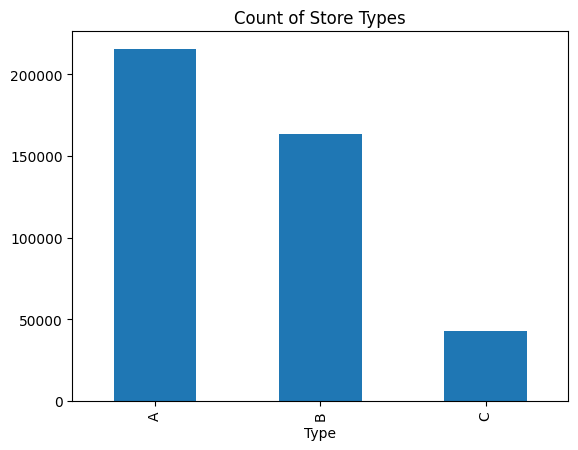

In [82]:
#bar plot
df['Type'].value_counts().plot(kind='bar')
plt.title("Count of Store Types")      
plt.show()

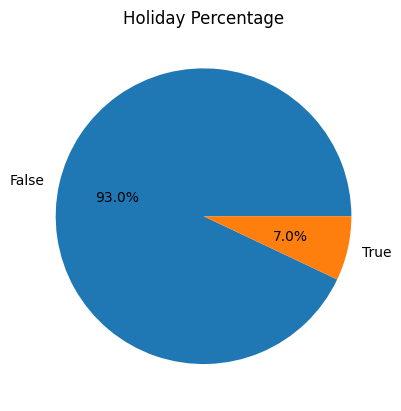

In [83]:
#pie chart
df['IsHoliday_x'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Holiday Percentage")
plt.ylabel('') 
plt.show()

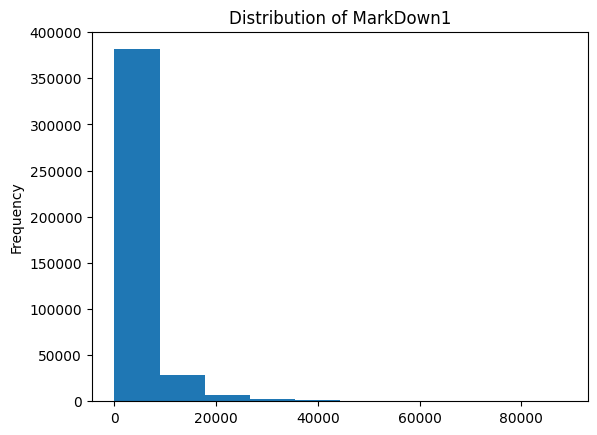

In [84]:
#histogram
df['MarkDown1'].plot(kind='hist')
plt.title("Distribution of MarkDown1")
plt.show()

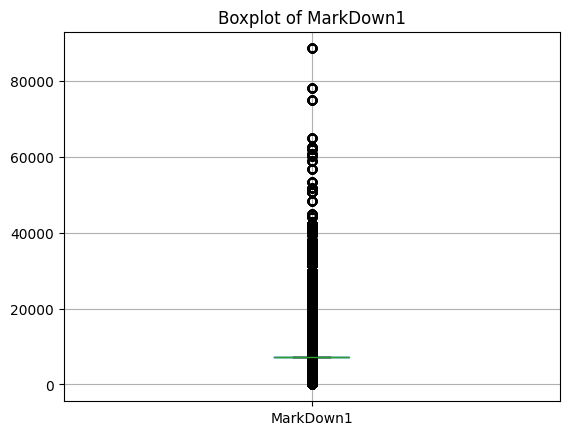

In [85]:
#boxplot
df.boxplot(column='MarkDown1')
plt.title("Boxplot of MarkDown1")
plt.show()

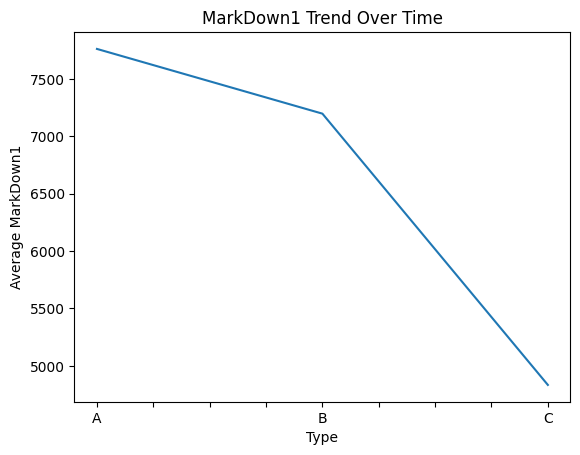

In [86]:
#line plot
df.groupby('Type')['MarkDown1'].mean().plot(kind='line')
plt.title("MarkDown1 Trend Over Time")
plt.xlabel("Type")
plt.ylabel("Average MarkDown1")
plt.show()

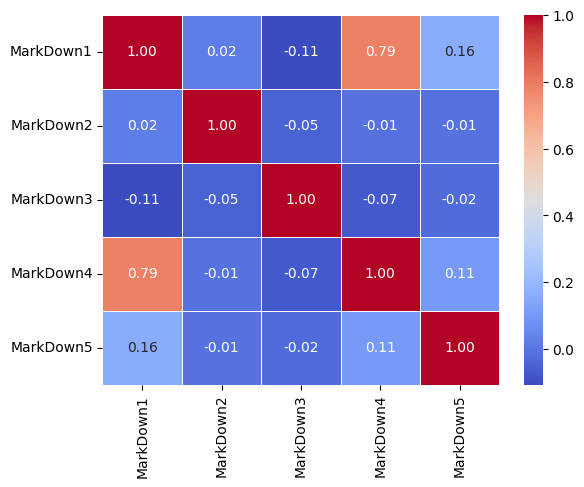

In [87]:
#Heatmap
sns.heatmap(df[['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.show()

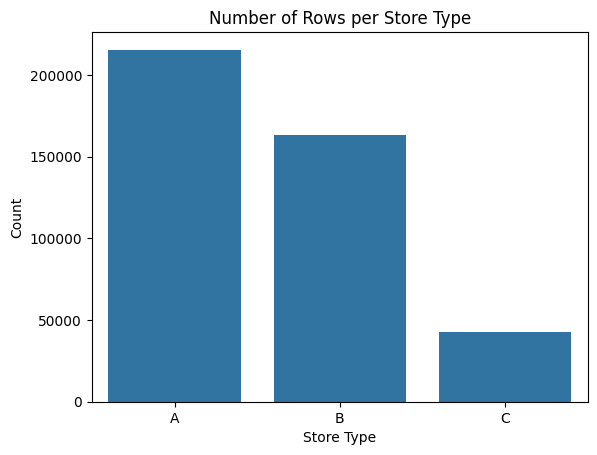

In [88]:
#countplot
sns.countplot(x='Type', data=df)
plt.title("Number of Rows per Store Type")
plt.xlabel("Store Type")
plt.ylabel("Count")
plt.show()

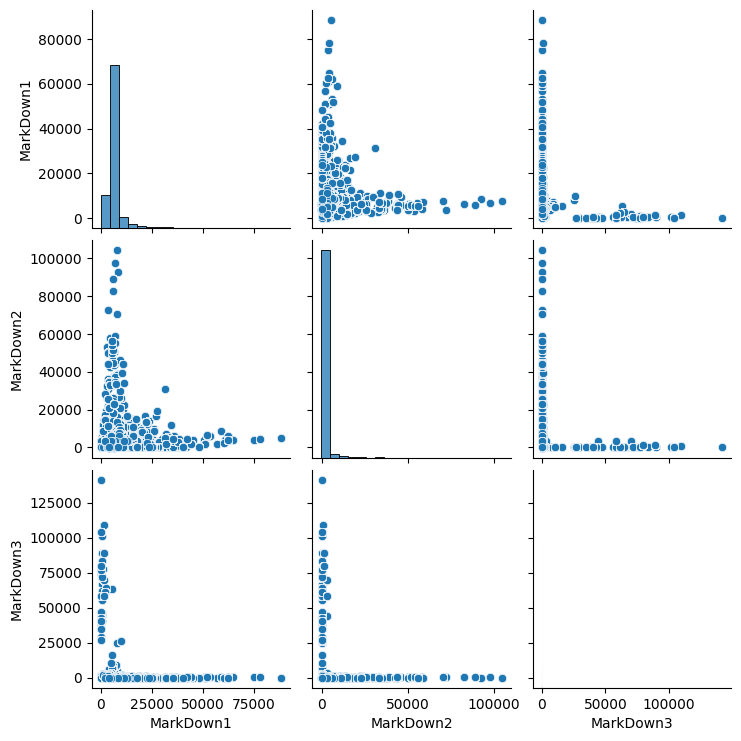

In [89]:
#pair plot
columns = df[['MarkDown1', 'MarkDown2', 'MarkDown3']]
sns.pairplot(columns)
plt.show()

In [ ]:
# Task 20-5-2026

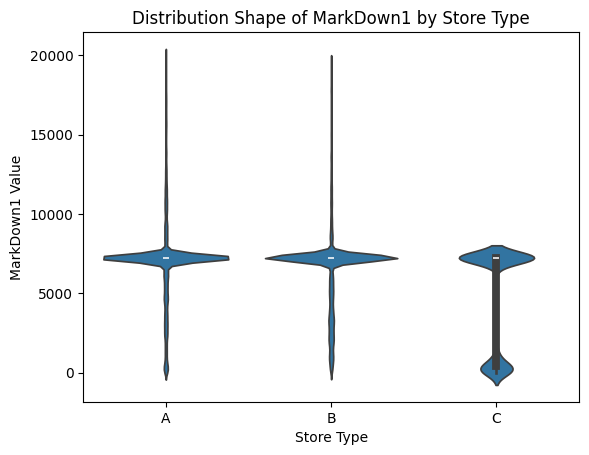

In [90]:
#violin plot
import seaborn as sns
filtered_df = df[df['MarkDown1'] < 20000].dropna(subset=['MarkDown1'])
sns.violinplot(x='Type', y='MarkDown1', data=filtered_df)
plt.title("Distribution Shape of MarkDown1 by Store Type")
plt.xlabel("Store Type")
plt.ylabel("MarkDown1 Value")
plt.show()

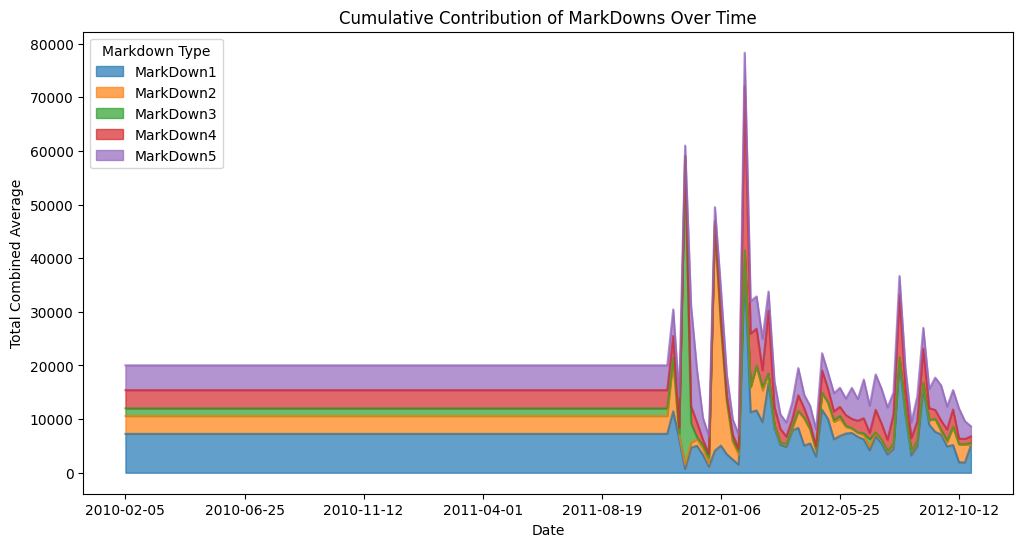

In [91]:
#Stacked Area Chart
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
weekly_markdowns = df.groupby('Date')[markdown_cols].mean()
weekly_markdowns.plot(kind='area', figsize=(12, 6), alpha=0.7)

plt.title("Cumulative Contribution of MarkDowns Over Time")
plt.xlabel("Date")
plt.ylabel("Total Combined Average")
plt.legend(title="Markdown Type", loc='upper left')
plt.show()

In [ ]:
# Observations
Count plot : Store Type A is the most frequent category in the dataset, accounting for the highest volume of records with over 200,000 rows.
Pair plot : All three markdown variables (MarkDown1, MarkDown2, and MarkDown3) are heavily right-skewed. The diagonal histograms show that the vast majority of values cluster very close to zero, with a long, sparse tail extending toward high promotional amounts. 
Heat map : There is a strong, positive correlation of 0.79 between MarkDown1 and MarkDown4, indicating that these two promotional strategies are frequently deployed together or fluctuate similarly.

In [92]:
#Data analysis class 20-5-26
df.corr(numeric_only=True)

,Store,Dept,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y,Size
Store,1.000000,0.024004,-0.085195,-0.000548,-0.050097,0.065290,-0.071460,-0.017445,-0.017935,-0.005343,-0.015976,-0.211088,0.208552,-0.000548,-0.182881
Dept,0.024004,1.000000,0.148032,0.000916,0.004437,0.003572,-0.001456,0.000148,0.001017,0.002385,0.000065,-0.007477,0.007837,0.000916,-0.002966
Weekly_Sales,-0.085195,0.148032,1.000000,0.012774,-0.002312,-0.000120,0.052208,0.013121,0.036018,0.026984,0.055405,-0.020921,-0.025864,0.012774,0.243828
IsHoliday_x,-0.000548,0.000916,0.012774,1.000000,-0.155949,-0.078281,-0.022472,0.198468,0.264071,-0.000340,-0.033993,-0.001944,0.010460,1.000000,0.000593
Temperature,-0.050097,0.004437,-0.002312,-0.155949,1.000000,0.143859,-0.023189,-0.162835,-0.052169,-0.034571,-0.010056,0.182112,0.096730,-0.155949,-0.058313
Fuel_Price,0.065290,0.003572,-0.000120,-0.078281,0.143859,1.000000,0.023104,-0.070184,-0.036553,-0.015774,-0.048429,-0.164210,-0.033853,-0.078281,0.003361
MarkDown1,-0.071460,-0.001456,0.052208,-0.022472,-0.023189,0.023104,1.000000,0.022747,-0.105646,0.785341,0.160079,-0.034201,0.027864,-0.022472,0.206346
MarkDown2,-0.017445,0.000148,0.013121,0.198468,-0.162835,-0.070184,0.022747,1.000000,-0.047662,-0.006580,-0.007010,-0.020744,0.009924,0.198468,0.051883
MarkDown3,-0.017935,0.001017,0.036018,0.264071,-0.052169,-0.036553,-0.105646,-0.047662,1.000000,-0.069613,-0.024990,-0.013788,0.006771,0.264071,0.027068
MarkDown4,-0.005343,0.002385,0.026984,-0.000340,-0.034571,-0.015774,0.785341,-0.006580,-0.069613,1.000000,0.105392,-0.028592,0.013013,-0.000340,0.084923
